In [ ]:

!pip install -q git+https://github.com/sarulab-speech/UTMOSv2.git


!pip install -q lightning openai-whisper jiwer speechbrain soundfile torchaudio transformers pandas tqdm librosa


  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [8]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
import soundfile as sf
import librosa
from tqdm.auto import tqdm
from dataclasses import dataclass
from transformers import GPT2LMHeadModel, GPT2TokenizerFast
from torch.utils.data import Dataset, DataLoader
import lightning as L

L.seed_everything(42)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

Seed set to 42


cuda


In [9]:
from kaggle_secrets import UserSecretsClient
from huggingface_hub import login

user_secrets = UserSecretsClient()
hf_token = user_secrets.get_secret("HF_TOKEN")
login(token=hf_token)

cell 3: dataset aquisition

In [10]:
root_dir = "./data"
os.makedirs(root_dir, exist_ok=True)

ljspeech_dataset = torchaudio.datasets.LJSPEECH(root=root_dir, download=True)

meta = pd.read_csv(f'{root_dir}/LJSpeech-1.1/metadata.csv', sep='|', header=None,
                   names=['id', 'text', 'text_norm'])
meta['text_norm'] = meta['text_norm'].fillna(meta['text'])
meta['filepath'] = meta['id'].apply(lambda s: f'{root_dir}/LJSpeech-1.1/wavs/{s}.wav')

rng = np.random.default_rng(42)
perm = rng.permutation(len(meta))
split_at = int(0.9 * len(meta))
train_df = meta.iloc[perm[:split_at]].reset_index(drop=True)
val_df   = meta.iloc[perm[split_at:]].reset_index(drop=True)

100%|██████████| 2.56G/2.56G [00:14<00:00, 191MB/s] 


4. audio codec

In [11]:
!pip install git+https://github.com/lucadellalib/focalcodec.git

  Cloning https://github.com/lucadellalib/focalcodec.git to /tmp/pip-req-build-1xu3x5r8
  Running command git clone --filter=blob:none --quiet https://github.com/lucadellalib/focalcodec.git /tmp/pip-req-build-1xu3x5r8
  Resolved https://github.com/lucadellalib/focalcodec.git to commit 912b7f2c0cd43d54a8aed296bbcc925dec7d4ea3
  Preparing metadata (setup.py) ... done
  Created wheel for focalcodec: filename=focalcodec-0.0.2-py3-none-any.whl size=49223 sha256=f3d1fde2c1b33f77fc8c83c9e53f2aaf9325ff05df18e98238c690b8510fec30
  Stored in directory: /tmp/pip-ephem-wheel-cache-1xen4nwy/wheels/8d/c6/c8/cec30556078947c251df506edcc38928b5bb208bdd569bc805
Successfully built focalcodec


In [12]:
from focalcodec import FocalCodec

codec = FocalCodec.from_pretrained('lucadellalib/focalcodec_25hz').to(device).eval()
for p in codec.parameters(): 
    p.requires_grad_(False)

CODEBOOK_SIZE = int(codec.codebook.shape[0])
CODEC_SR = codec.sample_rate_input
tokenizer = GPT2TokenizerFast.from_pretrained('gpt2')

def load_wav_16k(path):
    arr, sr = sf.read(path, dtype='float32', always_2d=False)
    if arr.ndim > 1: arr = arr.mean(-1)
    wav = torch.from_numpy(arr)
    if sr != CODEC_SR: wav = torchaudio.functional.resample(wav, sr, CODEC_SR)
    return wav

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/577M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

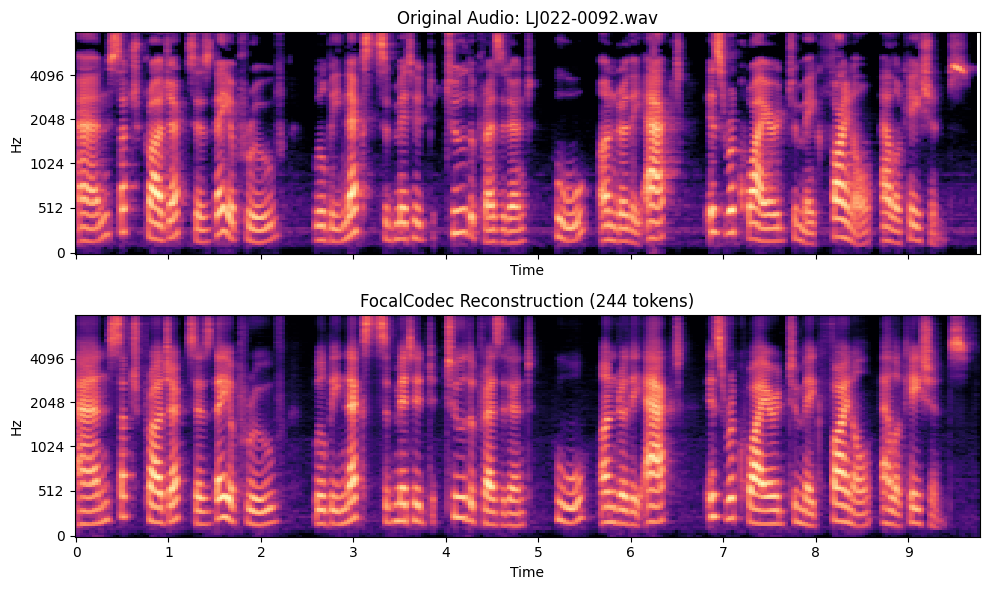

--- Original Audio ---


--- Reconstructed (Codec) Audio ---


In [13]:
import matplotlib.pyplot as plt
import librosa.display
from IPython.display import Audio, display

def visualize_results(path, label="Original"):
    wav = load_wav_16k(path).to(device)
    
    with torch.no_grad():
        tokens = codec.sig_to_toks(wav.unsqueeze(0))
        reconstructed = codec.toks_to_sig(tokens).squeeze(0).cpu().numpy()
    
    original_np = wav.cpu().numpy()
    
    fig, ax = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
    
    S_orig = librosa.feature.melspectrogram(y=original_np, sr=CODEC_SR)
    librosa.display.specshow(librosa.power_to_db(S_orig, ref=np.max), ax=ax[0], sr=CODEC_SR, x_axis='time', y_axis='mel')
    ax[0].set_title(f"Original Audio: {os.path.basename(path)}")
    
    S_rec = librosa.feature.melspectrogram(y=reconstructed, sr=CODEC_SR)
    librosa.display.specshow(librosa.power_to_db(S_rec, ref=np.max), ax=ax[1], sr=CODEC_SR, x_axis='time', y_axis='mel')
    ax[1].set_title(f"FocalCodec Reconstruction ({tokens.shape[-1]} tokens)")
    
    plt.tight_layout()
    plt.show()

    print("--- Original Audio ---")
    display(Audio(original_np, rate=CODEC_SR))
    print("--- Reconstructed (Codec) Audio ---")
    display(Audio(reconstructed, rate=CODEC_SR))

sample_row = train_df.iloc[0]
visualize_results(sample_row['filepath'])

: Tokenization and Preprocessing

In [14]:
CACHE_DIR = os.path.join(root_dir, 'tokenized')
os.makedirs(CACHE_DIR, exist_ok=True)
TRAIN_CACHE = os.path.join(CACHE_DIR, 'train.pt')
VAL_CACHE   = os.path.join(CACHE_DIR, 'val.pt')

@torch.no_grad()
def encode_split(df, cache_path, batch_size=16, overwrite=False, limit=None):
    if os.path.exists(cache_path) and not overwrite:
        return torch.load(cache_path, weights_only=False)

    if limit: df = df.iloc[:limit]

    recs = df.to_dict('records')
    paths = [r['filepath'] for r in recs]
    order = np.argsort([os.path.getsize(p) for p in paths])
    out = [None] * len(recs)
    
    for start in tqdm(range(0, len(recs), batch_size), desc=f"Processing {cache_path}"):
        idxs = order[start:start+batch_size]
        wavs = [load_wav_16k(paths[i]) for i in idxs]
        lens = torch.tensor([w.numel() for w in wavs], dtype=torch.float32)
        L_batch = int(lens.max()); batch = torch.zeros(len(wavs), L_batch)
        for j, w in enumerate(wavs): batch[j, :w.numel()] = w
        batch = batch.to(device)
        toks = codec.sig_to_toks(batch, length=(lens/L_batch).to(device))
        tok_lens = ((lens/L_batch).to(device) * toks.shape[-1]).round().clamp(max=toks.shape[-1]).to(torch.long)
        
        for j, i in enumerate(idxs):
            text_ids = tokenizer.encode(recs[i]['text_norm'], add_special_tokens=False)
            out[i] = {
                'id': recs[i]['id'],
                'text': recs[i]['text_norm'],
                'text_ids': torch.tensor(text_ids, dtype=torch.long),
                'audio_ids': toks[j, :tok_lens[j]].to(torch.long).cpu(),
                'n_text': len(text_ids),
                'n_audio': tok_lens[j].item(),
            }
    torch.save(out, cache_path)
    return out

# Set limit to None for full training
train_items = encode_split(train_df, TRAIN_CACHE, limit=None)
val_items   = encode_split(val_df,   VAL_CACHE, limit=None)

Processing ./data/tokenized/train.pt:   0%|          | 0/737 [00:00<?, ?it/s]

Processing ./data/tokenized/val.pt:   0%|          | 0/82 [00:00<?, ?it/s]

Data loading ultimaties

In [15]:
class TokenizedLJSpeech(Dataset):
    def __init__(self, cache_path, max_total_len=1024):
        items = torch.load(cache_path, weights_only=False)
        self.items = [it for it in items if it["n_text"] + it["n_audio"] + 2 <= max_total_len]
    def __len__(self): return len(self.items)
    def __getitem__(self, i): return self.items[i]

def collate(batch):
    B = len(batch)
    text_lens = torch.tensor([b["text_ids"].numel() for b in batch], dtype=torch.long)
    audio_lens = torch.tensor([b["audio_ids"].numel() for b in batch], dtype=torch.long)
    text_ids = torch.zeros(B, int(text_lens.max()), dtype=torch.long)
    audio_ids = torch.zeros(B, int(audio_lens.max()), dtype=torch.long)
    for i, b in enumerate(batch):
        text_ids[i, : b["text_ids"].numel()] = b["text_ids"]
        audio_ids[i, : b["audio_ids"].numel()] = b["audio_ids"]
    return {"text_ids": text_ids, "text_lens": text_lens, "audio_ids": audio_ids, "audio_lens": audio_lens}

gpt2 tts architecture

In [ ]:
@dataclass
class GPT2TTSConfig:
    base_model: str = "gpt2"
    codebook_size: int = 8192
    n_special_tokens: int = 2

    @property
    def audio_vocab_size(self): return self.codebook_size + self.n_special_tokens
    @property
    def bos_id(self): return self.codebook_size
    @property
    def eos_id(self): return self.codebook_size + 1


class GPT2TTS(nn.Module):
    def __init__(self, cfg: GPT2TTSConfig):
        super().__init__()
        self.cfg = cfg
        self.base = GPT2LMHeadModel.from_pretrained(cfg.base_model)
        H, V = self.base.config.n_embd, cfg.audio_vocab_size
        self.audio_emb  = nn.Embedding(V, H)
        self.audio_head = nn.Linear(H, V, bias=False)
        nn.init.normal_(self.audio_emb.weight,  std=0.02)
        nn.init.normal_(self.audio_head.weight, std=0.02)
        self.base.train()

    def _build_inputs(self, text_ids, text_lens, audio_ids, audio_lens):
        """Pack variable-length text+audio into (B, L, H) with mask & labels.

        Layout per row (tl = text_len, al = audio_len):
          pos:  0..tl-1   tl     tl+1..tl+al   tl+al+1   tl+al+2..L-1
          tok:  text      BOS    audio          EOS        PAD
          lbl:  -100      -100   audio          EOS        -100
        """
        B, device = text_ids.size(0), text_ids.device
        L = int((text_lens + audio_lens + 2).max().item())
        inputs = torch.zeros(B, L, self.base.config.n_embd, device=device)
        mask   = torch.zeros(B, L, dtype=torch.long,  device=device)
        labels = torch.full( (B, L), -100, dtype=torch.long, device=device)

        text_emb_all = self.base.transformer.wte(text_ids)
        for i in range(B):
            tl, al = int(text_lens[i].item()), int(audio_lens[i].item())
            inputs[i, :tl]           = text_emb_all[i, :tl];  mask[i, :tl]           = 1
            inputs[i, tl]            = self.audio_emb.weight[self.cfg.bos_id]
            mask[i, tl]              = 1
            inputs[i, tl+1:tl+1+al] = self.audio_emb(audio_ids[i, :al])
            mask[i,   tl+1:tl+1+al] = 1;  labels[i, tl+1:tl+1+al] = audio_ids[i, :al]
            inputs[i, tl+al+1]      = self.audio_emb.weight[self.cfg.eos_id]
            mask[i,   tl+al+1]      = 1;  labels[i, tl+al+1]       = self.cfg.eos_id
        return inputs, mask, labels

    def forward(self, text_ids, text_lens, audio_ids, audio_lens):
        inputs, mask, labels = self._build_inputs(
            text_ids, text_lens, audio_ids, audio_lens)
        h = self.base.transformer(
            inputs_embeds=inputs, attention_mask=mask,
            return_dict=True).last_hidden_state
        logits = self.audio_head(h)                          
        shift_logits = logits[:, :-1].float().contiguous()
        shift_labels = labels[:, 1:].contiguous()
        loss = F.cross_entropy(
            shift_logits.view(-1, shift_logits.size(-1)),
            shift_labels.view(-1), ignore_index=-100)
        return {"loss": loss, "logits": logits}

    @torch.no_grad()
    def generate_audio(
            self, text_ids,
            max_new_tokens: int   = 400,
            temperature:    float = 0.9,
            top_k:          int   = 50,
            top_p:          float = 1.0,
            greedy:         bool  = False,
    ) -> torch.Tensor:
        """Autoregressively sample audio tokens conditioned on text_ids.

        Sampling strategies (applied in order):
          greedy      – argmax (ignores temperature / top_k / top_p)
          top_k > 0   – keep only k highest-prob tokens
          top_p < 1   – nucleus: keep smallest set with cumulative prob >= p
          temperature – scale logits before softmax
        """
        
        was_training = self.training
        self.eval()
        try:
            device   = text_ids.device
            text_emb = self.base.transformer.wte(
                text_ids.view(-1).long()).unsqueeze(0)         # (1, T, H)
            bos      = self.audio_emb.weight[self.cfg.bos_id].view(1, 1, -1)
            prefix   = torch.cat([text_emb, bos], dim=1)      # (1, T+1, H)
            out      = self.base.transformer(
                inputs_embeds=prefix, use_cache=True, return_dict=True)
            past     = out.past_key_values
            h        = out.last_hidden_state[:, -1, :]         # (1, H)

            generated = []
            for _ in range(max_new_tokens):
                logits = self.audio_head(h).squeeze(0).float() # (V,)

                if greedy:
                    next_id = int(logits.argmax().item())
                else:
                    logits = logits / max(temperature, 1e-8)
                    if top_k > 0:
                        kth    = torch.topk(logits, min(top_k, logits.size(-1))).values[-1]
                        logits = logits.masked_fill(logits < kth, -float("inf"))
                    if 0.0 < top_p < 1.0:
                        sorted_logits, sorted_idx = torch.sort(logits, descending=True)
                        cum_probs = torch.cumsum(F.softmax(sorted_logits, dim=-1), dim=-1)
                        remove       = cum_probs - F.softmax(sorted_logits, dim=-1) > top_p
                        sorted_logits = sorted_logits.masked_fill(remove, -float("inf"))
                        logits = torch.zeros_like(logits).scatter_(0, sorted_idx, sorted_logits)
                    next_id = int(torch.multinomial(F.softmax(logits, dim=-1), 1).item())

                if next_id == self.cfg.eos_id:
                    break
                generated.append(next_id)
                tok_emb = self.audio_emb(torch.tensor([[next_id]], device=device))
                out     = self.base.transformer(
                    inputs_embeds=tok_emb, past_key_values=past,
                    use_cache=True, return_dict=True)
                past = out.past_key_values
                h    = out.last_hidden_state[:, -1, :]

        finally:
            self.train(was_training)  # always restore
        return torch.tensor(generated, dtype=torch.long, device=device)


training pipeline

In [ ]:
from lightning.pytorch.callbacks import ModelCheckpoint, LearningRateMonitor


class GPT2TTSLightningModule(L.LightningModule):
    def __init__(self, cfg: GPT2TTSConfig, lr: float = 3e-4):
        super().__init__()
        self.cfg = cfg
        self.lr  = lr
        self.save_hyperparameters(ignore=["cfg"])   

        self.model = GPT2TTS(cfg)

    def training_step(self, batch, batch_idx):
        loss = self.model(**batch)["loss"]
        self.log("train_loss", loss, on_step=True, on_epoch=True,
                 prog_bar=True, sync_dist=True)
        return loss

    def validation_step(self, batch, batch_idx):
        loss = self.model(**batch)["loss"]
        self.log("val_loss", loss, on_epoch=True, prog_bar=True, sync_dist=True)

    def configure_optimizers(self):
        opt = torch.optim.AdamW(
            self.parameters(), lr=self.lr, weight_decay=1e-2)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            opt, T_max=self.trainer.max_epochs)
        return [opt], [{"scheduler": scheduler, "interval": "epoch"}]


train_dl = DataLoader(
    TokenizedLJSpeech(TRAIN_CACHE),
    batch_size=8, shuffle=True,
    collate_fn=collate, num_workers=2, pin_memory=True)

val_dl = DataLoader(
    TokenizedLJSpeech(VAL_CACHE),
    batch_size=8,
    collate_fn=collate, num_workers=2, pin_memory=True)

checkpoint_cb = ModelCheckpoint(
    monitor="val_loss", mode="min",
    filename="gpt2tts-{epoch:02d}-{val_loss:.3f}",
    save_top_k=1, verbose=True)
lr_monitor = LearningRateMonitor(logging_interval="epoch")

trainer = L.Trainer(
    max_epochs=3,
    accelerator="auto", devices=1,
    gradient_clip_val=1.0,            
    callbacks=[checkpoint_cb, lr_monitor],
    log_every_n_steps=20,
)

module = GPT2TTSLightningModule(GPT2TTSConfig())
trainer.fit(module, train_dl, val_dl)
trained_model = module.model.eval().to(device)
print("Training complete.  Best checkpoint:", checkpoint_cb.best_model_path)


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

Trainable params: 137 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 137 M                                                                                                
Total estimated model params size (MB): 548                                                                        
Modules in train mode: 167                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

Epoch 0, global step 1474: 'val_loss' reached 7.91111 (best 7.91111), saving model to '/kaggle/working/lightning_logs/version_0/checkpoints/gpt2tts-epoch=00-val_loss=7.911.ckpt' as top 1
Epoch 1, global step 2948: 'val_loss' reached 7.43666 (best 7.43666), saving model to '/kaggle/working/lightning_logs/version_0/checkpoints/gpt2tts-epoch=01-val_loss=7.437.ckpt' as top 1
Epoch 2, global step 4422: 'val_loss' reached 7.21092 (best 7.21092), saving model to '/kaggle/working/lightning_logs/version_0/checkpoints/gpt2tts-epoch=02-val_loss=7.211.ckpt' as top 1
`Trainer.fit` stopped: `max_epochs=3` reached.


Training complete.  Best checkpoint: /kaggle/working/lightning_logs/version_0/checkpoints/gpt2tts-epoch=02-val_loss=7.211.ckpt


inference, evaluation

In [20]:
import tempfile
import utmosv2
import whisper
from jiwer import cer as jiwer_cer
from speechbrain.inference.speaker import EncoderClassifier

print("Loading ASR / MOS / Speaker-Encoder models …")
asr_model      = whisper.load_model("base")
utmos_model    = utmosv2.create_model()
spk_classifier = EncoderClassifier.from_hparams(
    source="speechbrain/spkrec-ecapa-voxceleb",
    run_opts={"device": "cpu"})
print("All models ready.\n")


MIN_TOKENS = 10

def toks_to_wav(toks: torch.Tensor) -> np.ndarray:
    """Convert audio token tensor (T,) to a numpy float32 waveform."""
    if toks.numel() < MIN_TOKENS:
        return np.zeros(CODEC_SR, dtype=np.float32)
    with torch.no_grad():
        wav = codec.toks_to_sig(
            toks.unsqueeze(0)          
        ).squeeze(0).cpu().numpy().astype(np.float32)
    return wav


def embed_spk(wav_np: np.ndarray, sr: int) -> torch.Tensor:
    t   = torchaudio.functional.resample(
        torch.from_numpy(wav_np).unsqueeze(0), sr, 16000)    
    emb = spk_classifier.encode_batch(t).squeeze()            
    return emb


def compute_metrics(wav: np.ndarray, sr: int,
                    text: str, ref_wav: np.ndarray):
    """Return (CER, UTMOS, SECS) for a generated waveform."""
    hyp     = asr_model.transcribe(
        wav.astype(np.float32), fp16=False)["text"].strip().lower()
    cer_val = jiwer_cer(text.lower(), hyp)

    wav_16k = torchaudio.functional.resample(
        torch.from_numpy(wav), sr, 16000).unsqueeze(0)        # (1, T)
    with tempfile.NamedTemporaryFile(suffix=".wav", delete=False) as tmp:
        tmp_path = tmp.name
    sf.write(tmp_path, wav, sr)
    try:
        mos_val = float(utmos_model.predict(input_path=tmp_path))
    finally:
        os.unlink(tmp_path)

    emb_gen  = embed_spk(wav,     sr)
    emb_ref  = embed_spk(ref_wav, sr)
    secs_val = F.cosine_similarity(
        emb_gen.unsqueeze(0), emb_ref.unsqueeze(0)).item()

    return cer_val, mos_val, secs_val


SAMPLING_STRATEGIES = [
    dict(name="Greedy",                greedy=True),
    dict(name="Top-k  (k=50, t=0.8)", greedy=False, temperature=0.8, top_k=50, top_p=1.0),
    dict(name="Nucleus(p=0.9, t=0.9)",greedy=False, temperature=0.9, top_k=0,  top_p=0.9),
]

SAMPLE_TEXTS = [
    "The quick brown fox jumps over the lazy dog.",
    "Speech synthesis has advanced significantly with deep learning.",
    "Lightning strikes the mountain top at midnight.",
    "Scientists discovered a new species of deep-sea fish.",
]

ref_wav = load_wav_16k(val_df.iloc[0]["filepath"]).numpy()

print(f"{'Text':<52} {'Strategy':<28} CER    UTMOS  SECS")
print("-" * 110)

results = []
for text in SAMPLE_TEXTS:
    text_ids = torch.tensor(
        tokenizer.encode(text, add_special_tokens=False), device=device)

    for strat in SAMPLING_STRATEGIES:
        strat_name = strat.pop("name")
        with torch.no_grad():
            toks = trained_model.generate_audio(text_ids, **strat)
        strat["name"] = strat_name

        wav = toks_to_wav(toks)
        cer_v, mos_v, secs_v = compute_metrics(wav, CODEC_SR, text, ref_wav)
        results.append(dict(text=text, strategy=strat_name,
                            cer=cer_v, utmos=mos_v, secs=secs_v,
                            n_tokens=toks.numel(), dur_s=len(wav)/CODEC_SR))

        short = (text[:49] + "…") if len(text) > 50 else text
        print(f"{short:<52} {strat_name:<28} {cer_v:.3f}  {mos_v:.3f}  {secs_v:.3f}")

print()
print("=== Average metrics per sampling strategy ===")
df_res = pd.DataFrame(results)
print(df_res.groupby("strategy")[["cer","utmos","secs"]].mean().round(3).to_string())


Loading ASR / MOS / Speaker-Encoder models …


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     |  | 
-----------------------------+------------+--+-
project_hid.weight           | UNEXPECTED |  | 
quantizer.weight_proj.bias   | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 
project_hid.bias             | UNEXPECTED |  | 
quantizer.weight_proj.weight | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 
project_q.bias               | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded checkpoint from /root/.cache/utmosv2/models/fusion_stage3/fold0_s42_best_model.pth
All models ready.

Text                                                 Strategy                     CER    UTMOS  SECS
--------------------------------------------------------------------------------------------------------------


Predicting:   0%|          | 0/1 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/utmosv2/_core/model/_common.py:290: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Predicting: 100%|██████████| 1/1 [00:06<00:00,  6.83s/it]


...

Scientists discovered a new species of deep-sea f…   Greedy                       0.717  2.377  0.455


Predicting: 100%|██████████| 1/1 [00:01<00:00,  1.16s/it]


Scientists discovered a new species of deep-sea f…   Top-k  (k=50, t=0.8)         0.736  2.639  0.279


Predicting: 100%|██████████| 1/1 [00:01<00:00,  1.34s/it]


Scientists discovered a new species of deep-sea f…   Nucleus(p=0.9, t=0.9)        0.774  2.730  0.368

=== Average metrics per sampling strategy ===
                         cer  utmos   secs
strategy                                  
Greedy                 0.731  2.633  0.385
Nucleus(p=0.9, t=0.9)  0.812  3.149  0.353
Top-k  (k=50, t=0.8)   0.747  3.245  0.356
